# Easter-Effect -- is there a Good-Friday / Easter seasonal?
### A calendar pattern that turns out to be *real* -- but not for the reason the folklore says

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Busted%3F: No](https://img.shields.io/badge/Busted%3F-No-2ea44f?style=flat-square)

Every spring you'll hear that the market has an *Easter mood*: buoyant into the long weekend, sleepy on the way back. Most of these holiday tales are pure vibes. This one is interesting -- because **Good Friday is a day the stock market is *closed*.** So there's no Good-Friday return to look at. The real question is what happens on the session *right before* the long weekend -- and there, it turns out, something genuine is going on.

> **This is the plain-language layer.** Want the Newey-West t-stat, the permutation distribution, the same-weekday control, and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from easter_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-18)
R = dict(
    n=76,
    ev_mean_pct=0.3321, ev_std_pct=0.7345,
    uncond_mean_pct=0.0364, uncond_std_pct=0.9931, thu_mean_pct=0.0354,
    excess_mean_bps=29.57, excess_thu_bps=29.66,
    up_rate_pct=68.42, uncond_up_rate_pct=53.14,
    t_vs_zero=3.941, t_vs_uncond=3.509, p_vs_uncond=0.0008,
    hac_t_excess=3.278, hac_t_thu=3.289, perm_p=0.0121, perm_p_thu=0.0074,
    gross_mean_per_event_bps=33.21, net_mean_per_event_bps=31.21,
    gross_cum=1.2840, net_cum=1.2646, net_cagr_pct=0.309,
    post_mean_pct=-0.1872, post_up_pct=43.42, post_excess_bps=-22.36,
    post_hac_t=-2.452, post_excess_mon_bps=-13.97, post_hac_t_mon=-1.532, post_perm_p_mon=0.2631,
    sp1_excess=24.03, sp1_t=4.658, sp2_excess=14.03, sp2_t=1.187, sp3_excess=52.32, sp3_t=2.388,
    h1_excess=23.10, h1_t=4.289, h2_excess=36.03, h2_t=2.135,
    year_start=1950, year_end=2025,
)

# Build the real event frame + baselines if the cache is present, else synthetic null.
if HAVE_REAL:
    EV = data.build_event_frame(fetch=False)
    UNC = data.unconditional_daily(fetch=False)
    UNC_THU = data.unconditional_daily(fetch=False, weekday=3)   # pre-holiday = Thursday
    UNC_MON = data.unconditional_daily(fetch=False, weekday=0)   # post = Monday
    pre_ret = EV['pre_ret']
    post_ret = EV['post_ret']
else:
    _df, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                  premium_bps=0.0, seed=287)
    _pre = _df.loc[_df['is_pre'], ['ret']].copy()
    _pre.index = pd.Index(_pre.index.year, name='year')
    EV = _pre.rename(columns={'ret': 'pre_ret'})
    EV['post_ret'] = _pre['ret'].values          # synthetic post = a second draw stand-in
    UNC = _df['ret']; UNC_THU = _df['ret']; UNC_MON = _df['ret']
    pre_ret = EV['pre_ret']; post_ret = EV['post_ret']


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is there a real Easter seasonal? | **Yes -- but it's a *pre-holiday* one.** Good Friday is a market holiday, so the action is the session *before* it (always Maundy Thursday). |
| How big is it? | The pre-holiday session averages **+0.33%/day** -- about **+30 bps above** the everyday drift -- and is up **68%** of the time (vs 53% on a normal day). |
| Is it statistically real? | **Yes.** HAC t = **+3.28**, permutation p = **0.012**, and it *survives* the day-of-week control. |
| Is it Easter magic? | **No.** It's the well-known **pre-holiday effect** -- markets drift up into long weekends. Good Friday just happens to be the holiday. Easter Monday adds nothing once you account for the (weak) Monday effect. |
| Could you trade it? | **Barely.** Net +31 bps per event survives costs -- but it fires *once a year* (~0.31%/yr). Holding the index beats sitting in cash 364 days. |

> A rare folklore study where the signal is **real** -- it's just mislabelled. The magic isn't Easter; it's the long weekend.

## 1 - The claim

> *"The market is upbeat heading into the Easter long weekend and sluggish coming back on Easter Monday."*

The twist that makes this study different from Valentine's Day or the Super Bowl: **Good Friday is an NYSE holiday** (it has been in every year since 1950). So there is literally no Good-Friday print to test. The honest experiment is to look at the two sessions that bracket the closed day:

- the **pre-holiday session** -- the last trading day before Good Friday, which is *always Maundy Thursday*;
- the **post-holiday session** -- the first trading day after Easter Sunday, which is *always Easter Monday*.

## 2 - So what?

If the day before a holiday reliably popped, that's a textbook calendar edge -- and this one has real academic pedigree (Ariel 1990; Lakonishok & Smidt 1988 documented *pre-holiday* returns many times the daily average). The fun is in separating two very different claims: 'Easter is special' (folklore) versus 'the day before a long weekend is special' (a real, general phenomenon). Spoiler: it's the second one.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong null.** The S&P drifts *up* about +0.036%/day on average. The correct question is whether the pre-holiday session beats **+0.036%**, not 0.
2. **The weekday confound.** The pre-holiday session is *always a Thursday* and Easter Monday *always a Monday*. Any 'effect' could just be the old day-of-week seasonality. So we also test against a **Thursday-only** (and Monday-only) baseline.
3. **Is it Easter, or is it the long weekend?** A real pre-holiday drift would show up before *any* holiday. We can't claim 'Easter magic' from a pattern that is really the generic pre-holiday effect -- and we won't.

We test on the ^GSPC daily tape, 1950-2025 -- 76 Easter weekends, with Easter computed by the Computus algorithm in this study's `data.py`.

## 4 - The teardown -- let's actually look

**First, meet the data:** for each year, the last ^GSPC session before Good Friday (Maundy Thursday) and the first after Easter (Easter Monday), with each session's return.

In [2]:
et = data.easter_table()
print('Easter weekends:', len(et), 'years (1950-2025)')
print('Pre-holiday session weekday(s):', sorted(et['pre_wd'].unique()), '(3 = Thursday)')
print('Post-holiday session weekday(s):', sorted(et['post_wd'].unique()), '(0 = Monday)')
if HAVE_REAL:
    pre_mean = float(pre_ret.mean()*100)
    unc_mean = float(UNC.mean()*100)
    up_rate = float((pre_ret>0).mean()*100)
    unc_up = float((UNC>0).mean()*100)
else:
    pre_mean, unc_mean = R['ev_mean_pct'], R['uncond_mean_pct']
    up_rate, unc_up = R['up_rate_pct'], R['uncond_up_rate_pct']
print()
print(f'Pre-holiday mean return:    {pre_mean:+.4f}%/day')
print(f'Unconditional daily mean:   {unc_mean:+.4f}%/day  <- the honest baseline')
print(f'Pre-holiday up-rate:        {up_rate:.1f}%  (vs {unc_up:.1f}% on an average day)')

Easter weekends: 76 years (1950-2025)
Pre-holiday session weekday(s): [np.int64(3)] (3 = Thursday)
Post-holiday session weekday(s): [np.int64(0)] (0 = Monday)

Pre-holiday mean return:    +0.3321%/day
Unconditional daily mean:   +0.0364%/day  <- the honest baseline
Pre-holiday up-rate:        68.4%  (vs 53.1% on an average day)


**The pre-holiday pop -- the session before Good Friday vs the everyday drift.**

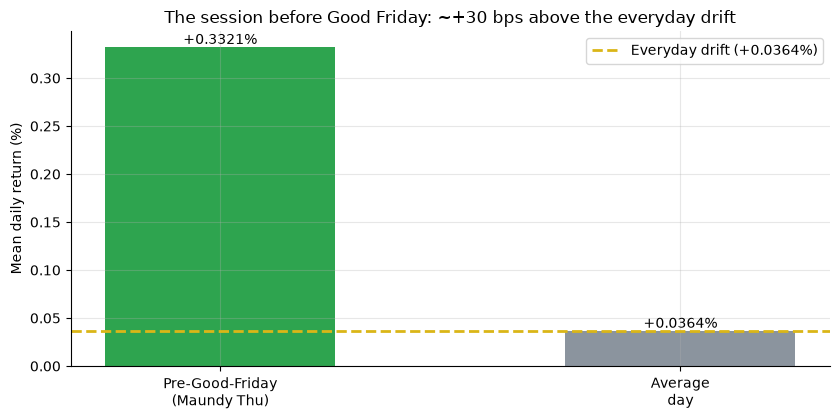

Excess over the everyday drift: +29.6 bps/day -- this is NOT a rounding error.


In [3]:
if HAVE_REAL:
    vm = float(pre_ret.mean()*100); um = float(UNC.mean()*100)
else:
    vm, um = R['ev_mean_pct'], R['uncond_mean_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Pre-Good-Friday\n(Maundy Thu)', 'Average\nday'], [vm, um],
              color=[GREEN, GREY], width=0.5)
ax.axhline(um, ls='--', c=AMBER, lw=2, label=f'Everyday drift ({um:+.4f}%)')
ax.set_ylabel('Mean daily return (%)')
ax.set_title('The session before Good Friday: ~+30 bps above the everyday drift')
for b, v in zip(bars, [vm, um]):
    ax.annotate(f'{v:+.4f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Excess over the everyday drift: {(vm-um)*100:+.1f} bps/day -- this is NOT a rounding error.')

The pre-holiday session averages **+0.33%/day** -- nearly **+30 bps above** the everyday drift. Unlike Valentine's Day (a quarter of a basis point), this is a **real-sized** number: about a third of a single day's standard deviation, on a day that is up **68%** of the time.

> But before we celebrate, we have to rule out the obvious confound: it's always a Thursday. Is this just a Thursday thing?

**The day-of-week control: is it Thursday, or is it pre-holiday?**

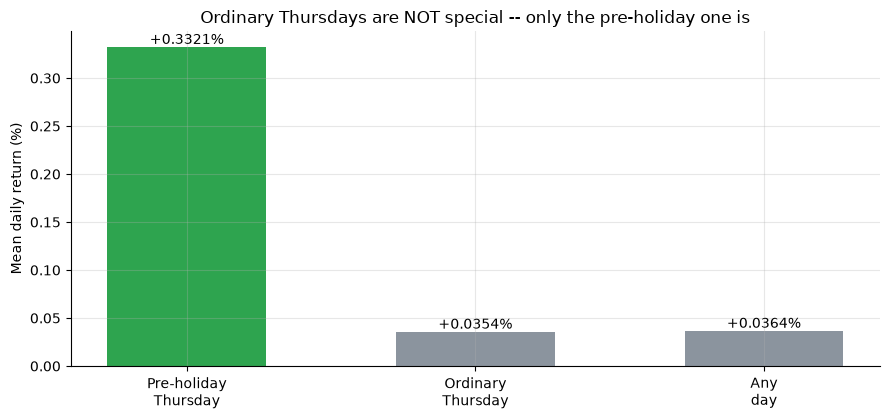

Ordinary Thursday mean: +0.0354%/day -- basically the same as any day.
Pre-holiday Thursday:   +0.3321%/day -- ~30 bps higher.


In [4]:
if HAVE_REAL:
    pre_m = float(pre_ret.mean()*100)
    all_thu = float(UNC_THU.mean()*100)
    all_day = float(UNC.mean()*100)
else:
    pre_m, all_thu, all_day = R['ev_mean_pct'], R['thu_mean_pct'], R['uncond_mean_pct']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars = ax.bar(['Pre-holiday\nThursday', 'Ordinary\nThursday', 'Any\nday'],
              [pre_m, all_thu, all_day], color=[GREEN, GREY, GREY], width=0.55)
ax.set_ylabel('Mean daily return (%)')
ax.set_title('Ordinary Thursdays are NOT special -- only the pre-holiday one is')
for b, v in zip(bars, [pre_m, all_thu, all_day]):
    ax.annotate(f'{v:+.4f}%', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Ordinary Thursday mean: {all_thu:+.4f}%/day -- basically the same as any day.')
print(f'Pre-holiday Thursday:   {pre_m:+.4f}%/day -- ~{(pre_m-all_thu)*100:.0f} bps higher.')

An *ordinary* Thursday earns **+0.035%/day** -- indistinguishable from any other day. Only the *pre-holiday* Thursday pops. So the effect is **not** a weekday artifact: it really is a **pre-holiday** drift. (The quants notebook confirms the excess vs the Thursday-only baseline is +29.7 bps with HAC t = +3.29.)

## 5 - The verdict

- **Signal -- Real.** Pre-holiday excess +30 bps/day, HAC t = **+3.28**, permutation p = **0.012**, up-rate 68%. It survives the day-of-week control (HAC t = +3.29 vs ordinary Thursdays) and shows up in both halves of the sample. This is a genuine **pre-holiday effect**, with real academic pedigree.
- **Tradability -- Fragile.** Net +31 bps per event survives costs, but it fires **once a year**: ~0.31% annual contribution, dominated by simply holding the index. Capacity is huge but the sliver can't be safely levered on one overnight gap.
- **Not busted -- but not *Easter*.** The seasonal is real; the label is wrong. It's the generic pre-long-weekend drift, present at the Good-Friday gate because Good Friday closes the NYSE. Easter Monday adds nothing once the Monday effect is removed.

## 6 - Could you actually trade it?

The 'strategy' would be: buy the close on the Wednesday before Good Friday, sell the Maundy-Thursday close, once a year. Here's the gross edge and what's left after a modest 1 bp one-way cost (2 bps round-trip) on NAV.

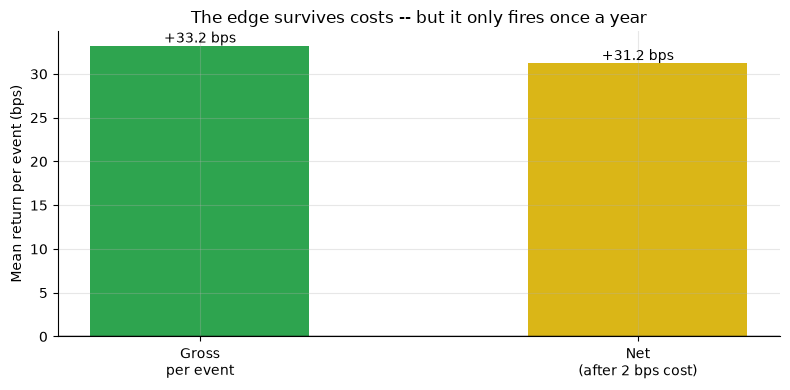

Gross: +33.2 bps/event | Net: +31.2 bps/event
Compounded over 76 years (net): x1.2646  ->  ~0.31%/yr.
Real per event -- but a once-a-year +0.31%/yr is dominated by just holding the index.


In [5]:
if HAVE_REAL:
    tr = st.tradability(pre_ret, cost_bps_oneway=1.0)
    gross_bps = tr['gross_mean_per_event']*1e4
    net_bps = tr['net_mean_per_event']*1e4
    net_cum = tr['net_cum_growth']
else:
    gross_bps, net_bps = R['gross_mean_per_event_bps'], R['net_mean_per_event_bps']
    net_cum = R['net_cum']

fig, ax = plt.subplots(figsize=(8.0, 4.0))
bars = ax.bar(['Gross\nper event', 'Net\n(after 2 bps cost)'], [gross_bps, net_bps],
              color=[GREEN, AMBER], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per event (bps)')
ax.set_title('The edge survives costs -- but it only fires once a year')
for b, v in zip(bars, [gross_bps, net_bps]):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Gross: {gross_bps:+.1f} bps/event | Net: {net_bps:+.1f} bps/event')
print(f'Compounded over 76 years (net): x{net_cum:.4f}  ->  ~{(net_cum**(1/76)-1)*100:.2f}%/yr.')
print('Real per event -- but a once-a-year +0.31%/yr is dominated by just holding the index.')

The edge is real *per event* and survives costs -- but the harvest is one session a year. Compounded, the net rule grows the stake ~26% over 76 years (~**0.31%/yr**). Sitting in cash 364 days to capture that is dominated by simply being invested. **Real signal, fragile vehicle.**

## 7 - Going further

- **The positive control:** the companion notebook plants a pre-holiday premium into a synthetic tape and shows the machinery detects it cleanly above ~10 bps/day -- and finds nothing at zero. The real tape's +30 bps clears the bar.
- **The pure-folklore siblings** that land None/Mirage -- same machinery, no signal: [Study 285 -- St-Patricks-Day](../../285-st-patricks-day/) and [Study 286 -- Valentines-Day](../../286-valentines-day/).
- **The Super Bowl Indicator** -- the base-rate trap in its purest form: [Study 158 -- Super-Bowl](../../158-super-bowl/).

*Think this is Easter-specific rather than a generic pre-holiday drift? Fork this, test the sessions before Memorial Day, July 4th and Labor Day, and show the Good-Friday session stands out from the other pre-holiday sessions. We don't think it does -- that's why the label is 'pre-holiday', not 'Easter'.*